main manual labler

In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from init_env import setup_environment
env = setup_environment()

# Setelah ini baru aman impor modul
from src.data_processing import parse_jdx, standardize_for_pattern_recognition

print("✅ Environment siap digunakan!")


📁 Project root: /home/acer/ai_spectrum_analysis_v2
📦 SRC path: /home/acer/ai_spectrum_analysis_v2/src
📦 DATA path: /home/acer/ai_spectrum_analysis_v2/data
🧠 Environment: Jupyter Notebook
✅ Modul 'data_processing' ditemukan.
✅ Environment siap digunakan!
✅ Environment siap digunakan!


visualize subtitition

manual labeling subtitution and labeling

In [2]:
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import json, os, pandas as pd, re
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from numpy.linalg import norm
from datetime import datetime
import pandas as pd
%matplotlib widget

class SpectrumLabeller_v2_2:
    def __init__(self, df, spectrum_id=None, user="user_x", 
                 file_path=None,
                 json_path="labels/labeled_regions.json",
                 feature_path="labels/features.npy",
                 mapping_path="labels/mapping.csv",
                 snippet_length=128,
                 canonical_dir="canonical",
                 smooth_snippet=True,
                 invert_absorbance=True):
        
        # --- [1] Auto derive cast_name & spectrum_id ---
        self.file_path = file_path
        if file_path:
            base = os.path.basename(file_path)
            cast_name = os.path.splitext(base)[0]
        elif spectrum_id:
            cast_name = spectrum_id.replace("spec_", "")
        else:
            cast_name = "unknown"

        self.cast_name = cast_name
        self.spectrum_id = spectrum_id or f"spec_{cast_name}"
        self.user = user
        self.invert_absorbance = invert_absorbance

        # --- [2] Paths & parameters ---
        self.json_path = json_path
        self.feature_path = feature_path
        self.mapping_path = mapping_path
        self.snippet_length = snippet_length
        self.canonical_dir = canonical_dir
        self.smooth_snippet = smooth_snippet
        self.df = df

        # --- [3] Inisialisasi penyimpanan ---
        os.makedirs(os.path.dirname(json_path) or ".", exist_ok=True)
        os.makedirs(canonical_dir, exist_ok=True)
        self.labels = []
        self.feature_matrix = self._load_existing_features()
        self.catalog = {}

        # --- [4] Setup plot + UI ---
        self._setup_plot()
        self._setup_widgets()
        display(self.controls_box)

    # ============================================================
    # Setup Plot dan Widget
    # ============================================================
    def _setup_plot(self):
        
        self.fig, self.ax = plt.subplots(figsize=(10, 5))
        self.ax.plot(self.df['wavenumber'], self.df['transmittance'], color='black', lw=1)
        self.ax.set_xlim(self.df['wavenumber'].max(), self.df['wavenumber'].min())
        self.ax.set_ylim(0, 1)
        # Always invert y-axis for both absorbance and transmittance
        
        self.ax.invert_yaxis()
        self.ax.set_title(f"Spectrum Labeling - {self.cast_name}")
        self.ax.set_xlabel("Wavenumber (cm⁻¹)")
        self.ax.set_ylabel("Transmittance (a.u.)")
        self.ax.grid(True, linestyle='--', alpha=0.3)
        self.selector = RectangleSelector(
            self.ax, self._onselect, useblit=True, interactive=True,
            props=dict(facecolor='orange', edgecolor='red', alpha=0.3, fill=True)
        )

    def _setup_widgets(self):
        self.label_text = widgets.Text(description='Label:', placeholder='misal: C=O stretch')
        self.save_button = widgets.Button(description='💾 Save Label', button_style='success')
        self.clear_button = widgets.Button(description='🗑️ Clear', button_style='danger')
        self.finish_button = widgets.Button(description='✅ Finish', button_style='info')
        self.output = widgets.Output()
        self.save_button.on_click(self._save_label)
        self.clear_button.on_click(self._clear_labels)
        self.finish_button.on_click(self._finish_session)
        self.controls_box = widgets.VBox([
            widgets.HBox([self.label_text, self.save_button, self.clear_button, self.finish_button]),
            self.output
        ])

    # ============================================================
    # Core utilities
    # ============================================================
    def _load_existing_features(self):
        if os.path.exists(self.feature_path):
            try:
                arr = np.load(self.feature_path)
                if arr.ndim == 1:
                    arr = arr.reshape(-1, self.snippet_length)
                return arr
            except Exception:
                return np.empty((0, self.snippet_length), dtype=np.float32)
        return np.empty((0, self.snippet_length), dtype=np.float32)

    def _onselect(self, eclick, erelease):
        self.x1, self.x2 = sorted([eclick.xdata, erelease.xdata])
        with self.output:
            clear_output(wait=True)
            print(f"📍 Area dipilih: {self.x2:.1f} – {self.x1:.1f} cm⁻¹")

    def _extract_snippet(self, start, end):
        df = self.df
        mask = (df['wavenumber'] <= start) & (df['wavenumber'] >= end)
        sub = df[mask]
        if len(sub) < 3:
            f = interp1d(df['wavenumber'], df['transmittance'], bounds_error=False, fill_value="extrapolate")
            x_grid = np.linspace(start, end, self.snippet_length)
            y = f(x_grid)
        else:
            f = interp1d(sub['wavenumber'], sub['transmittance'], bounds_error=False, fill_value="extrapolate")
            x_grid = np.linspace(start, end, self.snippet_length)
            y = f(x_grid)
        if self.smooth_snippet:
            from scipy.signal import savgol_filter
            y = savgol_filter(y, 7, 2, mode='nearest')
        y = (y - np.min(y)) / (np.max(y) - np.min(y) + 1e-12)
        return x_grid, y

    # ============================================================
    # Label handling
    # ============================================================
    def _save_label(self, _):
        if not hasattr(self, 'x1') or not hasattr(self, 'x2'):
            with self.output:
                print("⚠️ Pilih area dulu.")
            return
        label_name = self.label_text.value.strip()
        if not label_name:
            with self.output:
                print("⚠️ Masukkan nama label.")
            return

        x_grid, snippet = self._extract_snippet(self.x1, self.x2)
        center = float(np.mean([self.x1, self.x2]))
        label_id = f"label_{self.cast_name}_{len(self.labels)+1:03d}"
        entry = {
            "id": label_id,
            "spectrum_id": self.spectrum_id,
            "label": label_name,
            "range": {"start": float(self.x1), "end": float(self.x2)},
            "center": center,
            "intensity_mean": float(np.mean(snippet)),
            "intensity_min": float(np.min(snippet)),
            "intensity_max": float(np.max(snippet)),
            "points": int(len(snippet)),
            "snippet_index": int(len(self.feature_matrix)),
            "created_by": self.user,
            "created_at": datetime.now().isoformat()
        }
        self.labels.append(entry)
        self.feature_matrix = np.vstack([self.feature_matrix, snippet[np.newaxis, :]])
        self.ax.axvspan(self.x2, self.x1, color='orange', alpha=0.3)
        self.ax.text(center, 0.05, label_name, color='red', rotation=90, ha='center', va='bottom', fontsize=8)
        self.fig.canvas.draw_idle()
        with self.output:
            clear_output(wait=True)
            print(f"✅ Label '{label_name}' disimpan → {label_id}")

    def _clear_labels(self, _):
        self.labels = []
        with self.output:
            clear_output(wait=True)
            print("🧹 Label sementara dihapus (belum overwrite file).")

    # ============================================================
    # Finish session
    # ============================================================
    def _finish_session(self, _):
        meta_header = {
            "version": "2.2",
            "generated_at": datetime.now().isoformat(),
            "tool": "SpectrumLabeller_v2.2",
            "snippet_length": self.snippet_length,
            "source": self.cast_name
        }
        json_data = {"meta": meta_header, "labels": self.labels}
        with open(self.json_path, "w") as f:
            json.dump(json_data, f, indent=2)
        np.savez_compressed(self.feature_path.replace(".npy", "_compressed.npz"),
                            data=self.feature_matrix.astype(np.float16))
        cat_path, cat = self._compute_and_save_canonical(self.labels, self.feature_matrix)
        with self.output:
            clear_output(wait=True)
            print(f"💾 JSON → {self.json_path}")
            print(f"💾 Matrix (compressed) → {self.feature_path.replace('.npy', '_compressed.npz')}")
            print(f"🔖 Canonical catalog → {cat_path}")
            print(f"📦 Total label: {len(self.labels)}")

    # ============================================================
    # Canonical builder
    # ============================================================
    def _compute_and_save_canonical(self, all_labels, feature_matrix):
        os.makedirs(self.canonical_dir, exist_ok=True)
        df_labels = pd.DataFrame(all_labels)
        catalog = {}
        for label_name, group in df_labels.groupby("label"):
            indices = group["snippet_index"].astype(int).unique().tolist()
            snippets = feature_matrix[indices, :]
            mean_vec = np.mean(snippets, axis=0).astype(np.float32)
            std_vec = np.std(snippets, axis=0).astype(np.float32)
            safe = re.sub(r"[^a-zA-Z0-9_]+", "_", label_name)
            out_dir = os.path.join(self.canonical_dir, safe)
            os.makedirs(out_dir, exist_ok=True)
            np.save(os.path.join(out_dir, "mean.npy"), mean_vec)
            np.save(os.path.join(out_dir, "std.npy"), std_vec)
            meta = {
                "label": label_name,
                "n_examples": len(indices),
                "mean_path": os.path.join(out_dir, "mean.npy"),
                "std_path": os.path.join(out_dir, "std.npy")
            }
            with open(os.path.join(out_dir, "meta.json"), "w") as f:
                json.dump(meta, f, indent=2)
            catalog[label_name] = meta
        catalog_path = os.path.join(self.canonical_dir, "catalog.json")
        with open(catalog_path, "w") as f:
            json.dump(catalog, f, indent=2)
        return catalog_path, catalog


berhasil parse JCAMP-DX file.
Metadata: {'title': 'SALICYLIC ACID, ACETYL-', 'xunits': '1/CM', 'yunits': 'TRANSMITTANCE', 'data_type': 'INFRARED SPECTRUM', 'xfactor': 1.0, 'yfactor': 1.0}
spectrum_type: ir
processed_data:       wavenumber  absorbance
0    4000.000000    0.624966
1    3992.585170    0.624921
2    3985.170341    0.624875
3    3977.755511    0.624830
4    3970.340681    0.624775
..           ...         ...
495   329.659319    0.000000
496   322.244489    0.000000
497   314.829659    0.000000
498   307.414830    0.000000
499   300.000000    0.000000

[500 rows x 2 columns]
berhasil preprocess spectrum.
processed_data columns: Index(['wavenumber', 'absorbance'], dtype='object')
wavenumber type: <class 'pandas.core.series.Series'> absorbance type: <class 'pandas.core.series.Series'>


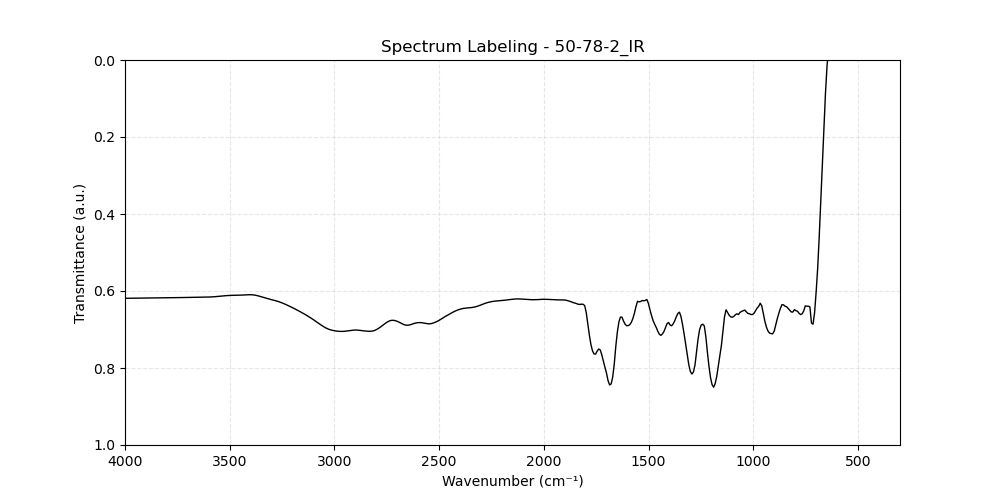

In [8]:
#data/samples_to_predict/50-78-2_IR.jdx
from src.data_processing import preprocess_spectrum, parse_jdx
import yaml
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
file_to_label = os.path.join(project_root, "data","samples_to_predict" ,"50-78-2_IR.jdx")
# Load config if not already loaded
config_path = os.path.join(project_root, 'main_config.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
# Parse spectrum file first
raw_data = parse_jdx(file_to_label)
if not raw_data:
    print("gagal parse JCAMP-DX file!.")
else:
    print("berhasil parse JCAMP-DX file.")
    print('Metadata:', raw_data.get('metadata', {}))

# Preprocess spectrum (standardizes to absorbance if needed)
spectrum_type = 'ir'  # or 'uv', set as appropriate for your data
print('spectrum_type:', spectrum_type)
processed_data = preprocess_spectrum(raw_data, config, spectrum_type)
print('processed_data:', processed_data)
if processed_data is None or len(processed_data) == 0:
    print("gagal preprocess spectrum!.")
else:
    print("berhasil preprocess spectrum.")
    print('processed_data columns:', processed_data.columns)
    print('wavenumber type:', type(processed_data['wavenumber']),'absorbance type:', type(processed_data['absorbance']))

data = processed_data

# Smooth the absorbance data using Savitzky-Golay filter
from scipy.signal import savgol_filter
window_length = 15 if len(data['absorbance']) >= 15 else (len(data['absorbance']) // 2) * 2 + 1
polyorder = 3 if window_length > 3 else 2
smoothed_y = savgol_filter(data['absorbance'], window_length=window_length, polyorder=polyorder)

# --- Do NOT invert for classic IR style (peaks down, y positive) ---
# smoothed_y = -smoothed_y  # <-- REMOVE THIS LINE

# --- Scale all spectra to average max value ---
# For a single spectrum, this is just scaling to a reference value.
# In a batch, you would compute the average max from all spectra.
reference_max = 0.85  # Example: use average max from your dataset, or set as needed
current_max = max(abs(smoothed_y)) if len(smoothed_y) > 0 else 1.0
if current_max == 0:
    scaled_y = smoothed_y
else:
    scale_factor = reference_max / current_max
    scaled_y = smoothed_y * scale_factor

# Build DataFrame for SpectrumLabeller_v2_2 using scaled_y
import pandas as pd
df = pd.DataFrame({'wavenumber': data['wavenumber'], 'transmittance': scaled_y})

tool = SpectrumLabeller_v2_2(df, file_path=file_to_label, user="fajrul", invert_absorbance=True)


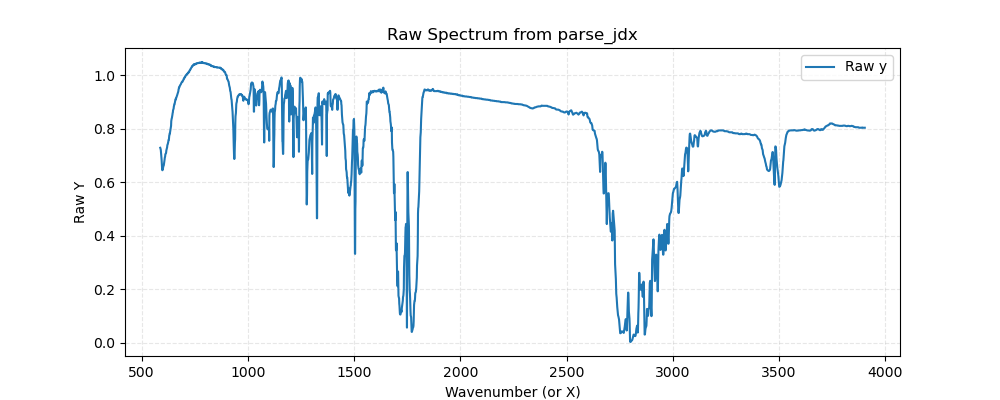

Raw y min: 0.0022
Raw y max: 1.05
Metadata: {'title': 'FORMALDEHYDE', 'xunits': '1/CM', 'yunits': 'TRANSMITTANCE', 'data_type': 'INFRARED SPECTRUM'}


In [10]:
# Debug: Plot raw spectrum before any processing
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(data['x'], data['y'], label='Raw y')
plt.xlabel('Wavenumber (or X)')
plt.ylabel('Raw Y')
plt.title('Raw Spectrum from parse_jdx')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.show()

print('Raw y min:', min(data['y']))
print('Raw y max:', max(data['y']))
print('Metadata:', data.get('metadata', {}))

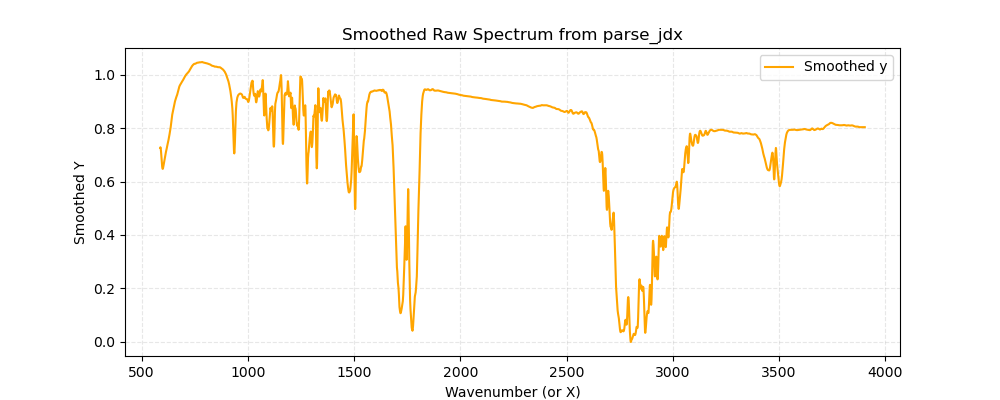

Smoothed y min: -0.0018679638009050062
Smoothed y max: 1.0483828054298703


In [11]:
# Debug: Plot smoothed spectrum (Savitzky-Golay)
from scipy.signal import savgol_filter

# Use a window length and polyorder suitable for IR spectra
window_length = 15 if len(data['y']) >= 15 else (len(data['y']) // 2) * 2 + 1
polyorder = 3 if window_length > 3 else 2

smoothed_y = savgol_filter(data['y'], window_length=window_length, polyorder=polyorder)

plt.figure(figsize=(10, 4))
plt.plot(data['x'], smoothed_y, label='Smoothed y', color='orange')
plt.xlabel('Wavenumber (or X)')
plt.ylabel('Smoothed Y')
plt.title('Smoothed Raw Spectrum from parse_jdx')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.show()

print('Smoothed y min:', min(smoothed_y))
print('Smoothed y max:', max(smoothed_y))